# TESS Target Pixel File (TPF) Exploration

This notebook explores TESS (Transiting Exoplanet Survey Satellite) Target Pixel Files (TPFs) for a given target across three sectors (43, 44, 45). TPFs contain small cutouts (e.g., 11×11 pixels) around a target star, with time-series flux measurements. We'll examine the first valid image for each sector and the aperture mask that defines which pixels are used to extract the light curve.

In [1]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt

In [2]:
# Plot style
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Georgia", "Times New Roman"],
    # ---- Sizes ----
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelweight": "light",  # x/y labels
    "font.weight": "light",
    # ---- Axes/ticks style like the PDF ----
    "axes.edgecolor": "0.2",
    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "axes.grid": False,
    "axes.labelcolor": "0.2",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.2",
})


%matplotlib widget

In [3]:
# Loading files for Sectors 43, 44, and 45. These files are 
# in FITS format and contain multiple HDUs (Header Data Units).

sector43_tpf = '43_tp.fits'
sector44_tpf = '44_tp.fits'
sector45_tpf = '45_tp.fits'

## Inspect FITS Structure

In [4]:
fits.info(sector43_tpf)

Filename: 43_tp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  PIXELS        1 BinTableHDU    248   17804R x 11C   [D, E, J, 121J, 121E, 121E, 121E, 121E, J, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 11)   int32   
  3  TARGET COSMIC RAY    1 BinTableHDU     27   0R x 4C   [J, I, I, E]   


In [5]:
tphdu43 = fits.open(sector43_tpf)

In [6]:
tphdu43[1].columns

ColDefs(
    name = 'TIME'; format = 'D'; unit = 'BJD - 2457000, days'; disp = 'D14.7'
    name = 'TIMECORR'; format = 'E'; unit = 'd'; disp = 'E14.7'
    name = 'CADENCENO'; format = 'J'; disp = 'I10'
    name = 'RAW_CNTS'; format = '121J'; unit = 'count'; null = -1; disp = 'I8'; dim = '(11,11)'
    name = 'FLUX'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'FLUX_ERR'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'FLUX_BKG'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'FLUX_BKG_ERR'; format = '121E'; unit = 'e-/s'; disp = 'E14.7'; dim = '(11,11)'
    name = 'QUALITY'; format = 'J'; disp = 'B16.16'
    name = 'POS_CORR1'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
    name = 'POS_CORR2'; format = 'E'; unit = 'pixel'; disp = 'E14.7'
)

## Display First Valid Images (Flux Maps)

We extract the first frame where the flux is finite (i.e., not NaN or zero) for each sector. The images are plotted with celestial coordinates (RA/Dec) using the World Coordinate System (WCS) from the aperture HDU header. This allows us to see the spatial distribution of the target and background stars."

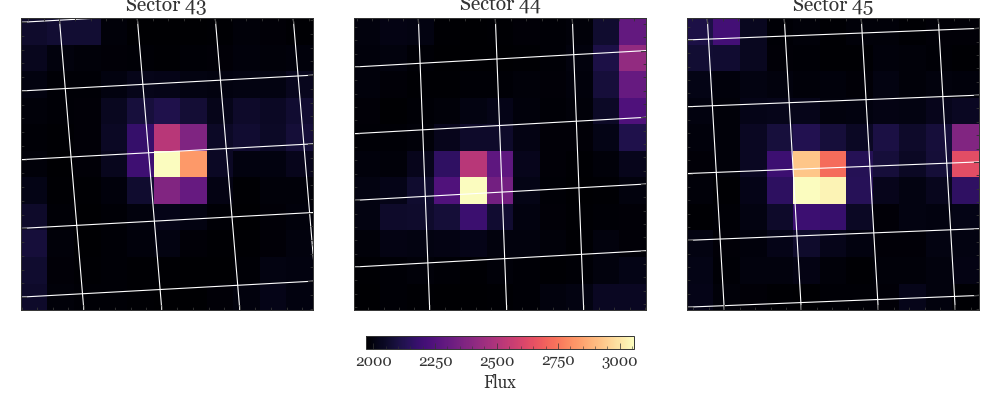

In [7]:

sectors = [sector43_tpf, sector44_tpf, sector45_tpf]
titles = ["Sector 43", "Sector 44", "Sector 45"]
images = []
wcs_list = []

# Load data and WCS for each sector
for sector in sectors:
    tphdu = fits.open(sector)
    tpf_data = tphdu[1].data

    # Find the first valid image
    for i_check in range(len(tpf_data['TIME'])):
        if np.isfinite(tpf_data['FLUX'][i_check][0, 0]):
            break

    # Extract the first valid image and WCS
    images.append(tpf_data['FLUX'][i_check])
    wcs_list.append(WCS(tphdu[2].header))  # Store individual WCS for each sector
    tphdu.close()

# Create the figure and subplots
fig = plt.figure(figsize=(10, 4), constrained_layout=True)

# Plot for Sector 43
ax1 = plt.subplot(1, 3, 1, projection=wcs_list[0])  # First WCS
im1 = ax1.imshow(images[0], origin='lower', cmap='magma')
ax1.set_xlabel('RA', fontsize=12)
ax1.set_ylabel('Dec', fontsize=12)
ax1.grid(axis='both', color='white', linestyle='solid')
ax1.set_title('Sector 43', fontsize=14)

# Plot for Sector 44
ax2 = plt.subplot(1, 3, 2, projection=wcs_list[1])  # Second WCS
im2 = ax2.imshow(images[1], origin='lower', cmap='magma')
ax2.set_xlabel('RA', fontsize=12)
ax2.set_ylabel('Dec', fontsize=12)
ax2.grid(axis='both', color='white', linestyle='solid')
ax2.set_title('Sector 44', fontsize=14)

# Plot for Sector 45
ax3 = plt.subplot(1, 3, 3, projection=wcs_list[2])  # Third WCS
im3 = ax3.imshow(images[2], origin='lower', cmap='magma')
ax3.set_xlabel('RA', fontsize=12)
ax3.set_ylabel('Dec', fontsize=12)
ax3.grid(axis='both', color='white', linestyle='solid')
ax3.set_title('Sector 45', fontsize=14)

# Add a shared colorbar below the plots
cbar = fig.colorbar(im3, ax=[ax1, ax2, ax3], orientation='horizontal', fraction=0.046, pad=0.08)
cbar.set_label('Flux', fontsize=12)

plt.show()


## Aperture Masks
 
 The aperture mask (HDU 2) defines which pixels are included in the photometric aperture. Non‑zero values indicate membership in the aperture. Different values represent different aperture types (e.g., default, custom, or background). The mask is used by the TESS pipeline to sum the flux for the target light curve. Below we display the masks for each sector.

In [8]:
for i, sector in enumerate(sectors, start=43):  # Start index at 43 for Sector numbers
    tphdu = fits.open(sector)
    ap_image = tphdu[2].data  # Extract data from the second HDU
    print(f"Sector {i} Aperture Image:\n", ap_image)
    tphdu.close()  # Close the file to free resources


Sector 43 Aperture Image:
 [[65 65 65 65 65 65 65 65 65 65 65]
 [65 65 69 65 69 69 69 69 69 65 65]
 [65 65 69 65 65 65 65 69 69 65 65]
 [65 65 69 65 65 65 65 65 69 65 65]
 [65 69 69 65 65 75 75 65 69 65 65]
 [65 69 65 65 75 75 75 65 65 65 65]
 [65 69 65 65 75 75 75 65 65 65 65]
 [65 69 65 65 65 75 65 65 65 65 65]
 [65 69 69 65 65 65 65 65 65 65 65]
 [65 65 65 65 69 69 69 69 69 69 65]
 [65 65 65 65 69 69 69 69 69 65 65]]
Sector 44 Aperture Image:
 [[133 133 133 133 133 133 129 129 129 129 129]
 [133 133 129 133 133 129 133 133 129 129 129]
 [129 129 129 129 129 129 129 129 133 129 129]
 [129 129 129 139 139 129 129 129 133 129 129]
 [129 129 129 139 139 139 129 129 133 129 129]
 [129 129 129 139 139 139 129 133 133 129 129]
 [129 129 129 129 139 139 129 129 133 129 129]
 [129 133 133 129 129 129 129 133 129 129 129]
 [129 133 133 133 129 129 129 129 129 129 129]
 [129 129 133 133 133 133 133 133 129 129 129]
 [129 129 129 129 129 129 129 129 129 129 129]]
Sector 45 Aperture Image:
 [[65

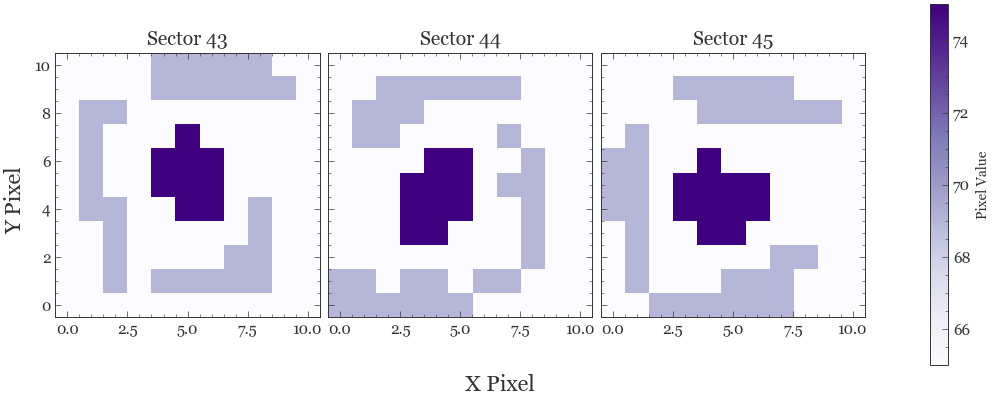

In [9]:
# Create a single figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True, sharex=True, sharey=True)

for i, (sector, ax) in enumerate(zip(sectors, axes)):
    tphdu = fits.open(sector)
    aperture = tphdu[2].data  # Extract the aperture bitmask
    
    # Plot the aperture bitmask with a purple colormap
    cbx = ax.imshow(aperture, cmap=plt.cm.Purples, origin="lower", alpha=1.0)
    
    # Set title for each subplot
    ax.set_title(titles[i], fontsize=14)
    
    tphdu.close()  # Close the FITS file

# Set shared X and Y labels
fig.supxlabel("X Pixel", fontsize=16)
fig.supylabel("Y Pixel", fontsize=16)

# Add a single colorbar shared across all subplots
cbar = fig.colorbar(cbx, ax=axes, orientation='vertical', fraction=0.046, pad=0.08)
cbar.set_label("Pixel Value", fontsize=10)

# Display the figure
plt.show()
